# Descriptive Statistics 

## What Are Descriptive Statistics?
* **Measures that summarize important features** of data
* Often condensed into a single number per feature
* Provide a quick overview of your dataset's characteristics    

## When to Use Them:
* **Common first step** after cleaning and preparing data
* Before diving into complex analysis or modeling
* Help you understand your data's basic properties

## Purpose:
* **Summarize** large amounts of data quickly
* **Identify patterns** and unusual values
* **Guide** further analysis decisions

## What We'll Cover
* Review familiar descriptive statistics functions
* Explore several **new functions** for data summary
* Learn how to interpret and use these measures effectively

## Types of Descriptive Statistics:
* **Central tendency:** Mean, median, mode
* **Variability:** Standard deviation, variance, range
* **Position:** Percentile, quartiles

## Mesaures of Center

Measures of center are statistics that give us a sense of the "middle" of a numeric variable. In other words, centrality measures give you a sense of a typical value you'd expect to see. Common measures of center include the mean, median and mode.

The mean is simply an average: the sum of the values divided by the total number of records. As we've seen in previous lessons we can use df.mean() to get the mean of each column in a DataFrame:

In [1]:
# Common imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load mtcars dataset
mtcars = pd.read_csv(r"/Users/cihan/Documents/GitHub/introduction-to-data-science---BLM22436E/week4/Week_4/mtcars.csv")

# Rename the first column to 'model'
mtcars = mtcars.rename(columns={"Unnamed: 0": "model"})

# Set the index to the 'model' column
mtcars.index = mtcars.model

# Delete the 'model' column as it's now the index
del mtcars["model"]

# Display the first few rows of the dataset
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
mtcars.mean()

mpg      20.090625
cyl       6.187500
disp    230.721875
hp      146.687500
drat      3.596563
wt        3.217250
qsec     17.848750
vs        0.437500
am        0.406250
gear      3.687500
carb      2.812500
dtype: float64

We can also get the means of each row by supplying an axis argument:

In [4]:
# Get the mean of each row
mtcars.mean(axis=1)

model
Mazda RX4              29.907273
Mazda RX4 Wag          29.981364
Datsun 710             23.598182
Hornet 4 Drive         38.739545
Hornet Sportabout      53.664545
Valiant                35.049091
Duster 360             59.720000
Merc 240D              24.634545
Merc 230               27.233636
Merc 280               31.860000
Merc 280C              31.787273
Merc 450SE             46.430909
Merc 450SL             46.500000
Merc 450SLC            46.350000
Cadillac Fleetwood     66.232727
Lincoln Continental    66.058545
Chrysler Imperial      65.972273
Fiat 128               19.440909
Honda Civic            17.742273
Toyota Corolla         18.814091
Toyota Corona          24.888636
Dodge Challenger       47.240909
AMC Javelin            46.007727
Camaro Z28             58.752727
Pontiac Firebird       57.379545
Fiat X1-9              18.928636
Porsche 914-2          24.779091
Lotus Europa           24.880273
Ford Pantera L         60.971818
Ferrari Dino           34.508182
Mase

In [5]:
# Get the median of each column
mtcars.median()

mpg      19.200
cyl       6.000
disp    196.300
hp      123.000
drat      3.695
wt        3.325
qsec     17.710
vs        0.000
am        0.000
gear      4.000
carb      2.000
dtype: float64

# Mean vs Median: Key Differences

## What They Measure:
* **Mean:** Numeric average of all values
* **Median:** Value that splits data into two equal halves

## How They Differ:
* **Median:** Stays stable even with outliers
* **Mean:** Gets "dragged" by very high or evry low values 

## In Symmetric Distributions:
* **Mean = Median** when data is perfectly balanced
* Both measures point to the same center

## In Skewed Distributions: 
* **Mean ≠ Median** when data is unbalanced
* Mean gets pulled toward the longer tail
* Median stays at the true middle

## Visual Investigation:
Let's use a **density plot** to see how mean and median behave in different distribution shapes:

In [6]:
!pip install scikit-learn

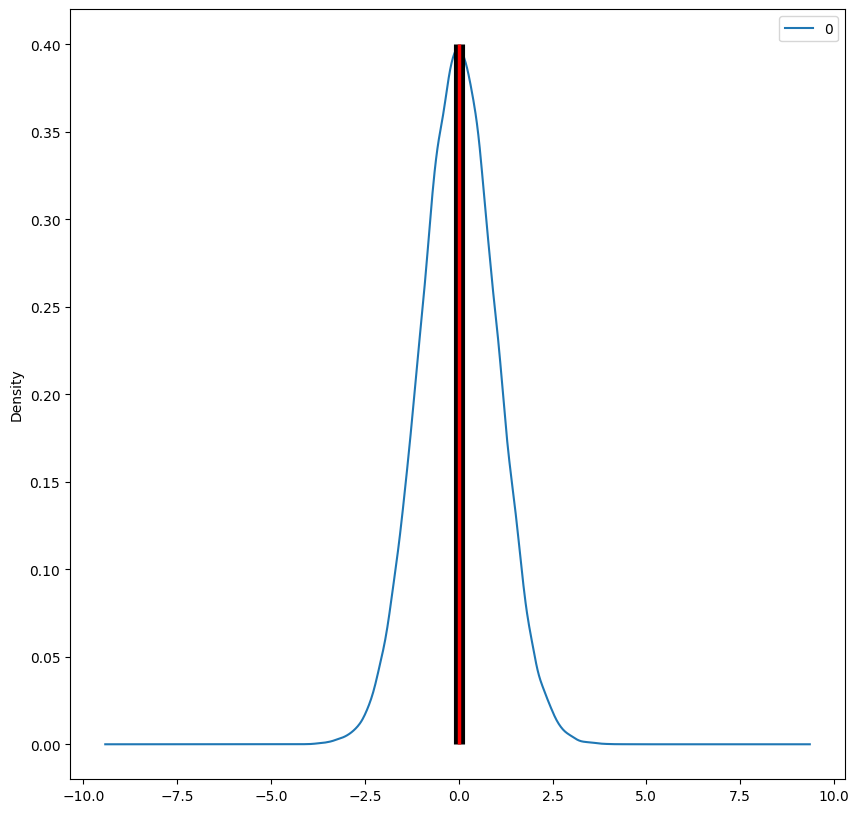

In [7]:
# Create a DataFrame with normally distributed data
norm_data = pd.DataFrame(np.random.normal(size=100000))

# Plot the density of the normally distributed data
norm_data.plot(kind="density", figsize=(10, 10))

# Plot black line at mean
plt.vlines(norm_data.mean(), ymin=0, ymax=0.4, linewidth=8.0, color="black")

# plot red line at median
plt.vlines(norm_data.median(), ymin=0, ymax=0.4, linewidth=2.5, color="red")

In the plot above the mean and median are both so close to zero that the red median line lies on top of the thicker black line drawn at the mean.

In skewed distributions, the mean tends to get pulled in the direction of the skew, while the median tends to resist the effects of skew:

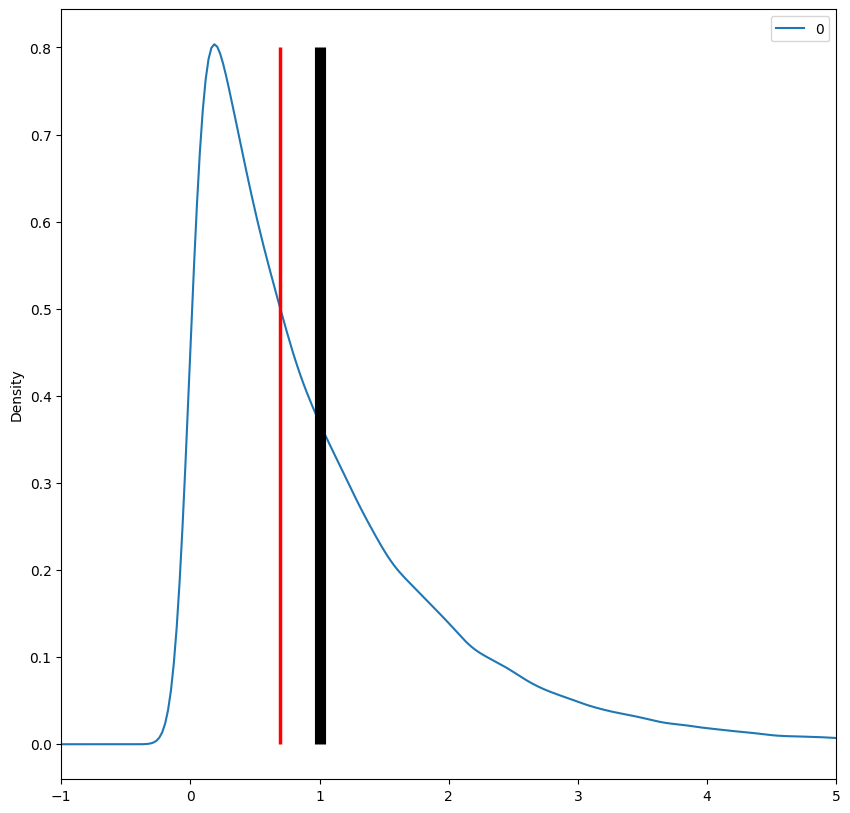

In [8]:
# Create a DataFrame with exponentially distributed data
skewed_data = pd.DataFrame(np.random.exponential(size=100000))

# Plot black lien at mean
skewed_data.plot(kind="density", figsize=(10, 10), xlim=(-1, 5))
plt.vlines(skewed_data.mean(), ymin=0, ymax=0.8, linewidth=8.0, color="black")

# Plot red line at median
plt.vlines(skewed_data.median(), ymin=0, ymax=0.8, linewidth=2.5, color="red")

The mean is also influenced heavily bby outliers, while the median resists the influence of outliers:

Since the median tends to resist the effects of skewness and outliers, it is known a "robust" statistic. The median generally gives a better sense of the tyoical value in a distribution with significant skew or outliers.

The mode of a variable is simply the value that appears most frequently. Unlike mean and median, you can take the mode of a categorical variable and it is possible to have multiple modes. Find the mode with df.mode():

In [9]:
# Get the mode of each column
mtcars.mode()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,10.4,8.0,275.8,110.0,3.07,3.44,17.02,0.0,0.0,3.0,2.0
1,15.2,NaN,NaN,175.0,3.92,NaN,18.90,NaN,NaN,NaN,4.0
2,19.2,NaN,NaN,180.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,22.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,30.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The columns with multiple modes (multiple values with the same count) return multiple values as the mode. Columns with no mode (no value that appear more than once) return NaN.

## Measures of Spread

### What Thet Measure:
* **Statistics that describe how data varies**
* Show how much data points differ from each other

### Why They Mattet:
* **Measures of center (mean, median) → tell us the typical value
* **Measures of spread** → tell us how much data diverges from the typical value
* Both are needed for a complete picture of your data

### Understanding Spread:
* **Low spread:** Data points cluster tightly around the center
* **High spread:** Data points are scattered widely from the center

## Range: The Simplest Measure

### What is Range?
* **Distance between maximum and minimum observations**
* Range = Maximum value - Minimum value

### Advantages:
* Very **easy to calculate** and understand
* Gives quick sense of data's total spread

### Limitations:
* Only uses **two data points** ignores everything in between
* **Sensitive to outliers** (one extreme value affects the entire measure)


In [11]:
# Measures of spread (dispersion) are statistics that describe how data varies.
# While measures of center give us an idea of the typical value, measures of spread give us a sense of how 
#  much the data tends to diverge from the typical value.
max(mtcars["mpg"]) - min(mtcars["mpg"])

23.5

## Percentiles and Quantiles

### Understanding Percentiles:
* **Median = 50th percentile** (splits data in half)
* Percentiles show what percentage of data falls below a given value

### Using Multiple Percentiles:
* A **summary of severeal percentiles** describe a variable's spread
* More robust than just using minimum and maximum
* Shows how data is distributed across the entire range

### The Five-Number Summary:
* Minimum value (0th percentile)
* First quartile (25th percentile)
* Second quartile (50th percentile)
* Thirde quartile (75th percentile)
* Maximum value (100th percentile)

### Extracting Percentiles:
* Use the `quantile()` function
* Can specify any percentile you want
* Provides a comprehensive view of data distribution

### Why This Matters:
* Shows **where most of your data lives**
* Identifies potential **outliers** (values far from quartiles)
* More informative than just range (min to max)

In [12]:
# quantile() function to get percentiles 
five_num = [mtcars["mpg"].quantile(0),   # Minimum
            mtcars["mpg"].quantile(0.25), # 25th percentile (Q1) - First Quartile - 25% of data is below this value
            mtcars["mpg"].quantile(0.50), # 50th percentile (Q2) - Median - 50% of data is below this value
            mtcars["mpg"].quantile(0.75), # 75th percentile (Q3) - Third Quartile - 75% of data is below this value
            mtcars["mpg"].quantile(1)]    # Maximum

five_num

[np.float64(10.4),
 np.float64(15.425),
 np.float64(19.2),
 np.float64(22.8),
 np.float64(33.9)]

* Since these values are so commonly used to describe data, they are known as the "five number summary".
* They are the same percentile values returned by df.describe():

In [13]:
# Get a summary of descriptive statistics for the 'mpg' column
mtcars["mpg"].describe()

count    32.000000
mean     20.090625
std       6.026948
min      10.400000
25%      15.425000
50%      19.200000
75%      22.800000
max      33.900000
Name: mpg, dtype: float64

* Interquartile (IQR) range is another common measure of spread.
* IQR is the distance between the 3rd quartile and the 1st quartile:

In [14]:
# Get the interquartile range (IQR) for the 'mpg' column
# IQR is the distance between the 3rd quartile and the 1st quartile
# IQR = Q3 - Q1
# IQR gives us an idea of the spread of the middle 50% of the data
mtcars["mpg"].quantile(0.75) - mtcars["mpg"].quantile(0.25)

np.float64(7.375)

The boxplots we learnede to create in the lesson on plotting are just visual representations of the five number summary and IQR:

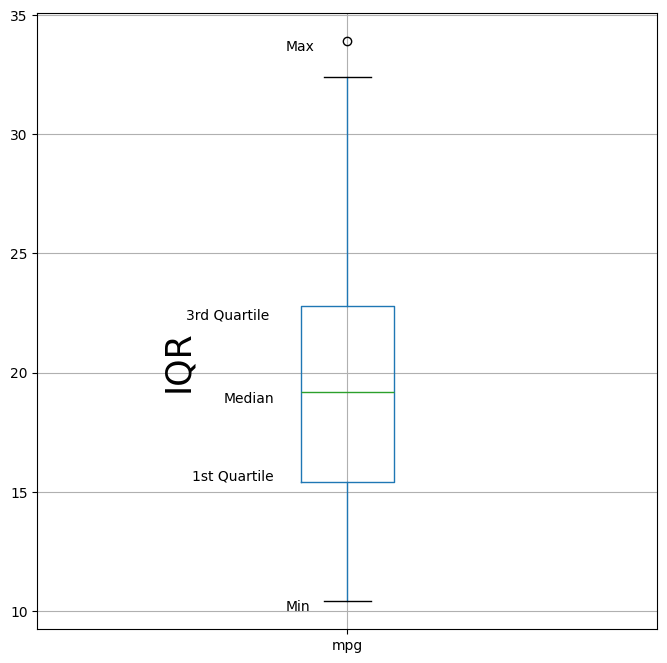

In [15]:
mtcars.boxplot(column="mpg",
               return_type='axes',
               figsize=(8,8))

plt.text(x=0.74, y=22.25, s="3rd Quartile") # 75th percentile (Q3) - Third Quartile - 75% of data is below this value
plt.text(x=0.8, y=18.75, s="Median") # 50th percentile (Q2) - Median - 50% of data is below this value
plt.text(x=0.75, y=15.5, s="1st Quartile") # 25th percentile (Q1) - First Quartile - 25% of data is below this value
plt.text(x=0.9, y=10, s="Min") # Minimum Value
plt.text(x=0.9, y=33.5, s="Max") # Maximum value
plt.text(x=0.7, y=19.5, s="IQR", rotation=90, size=25); # spread of the middle 50% of the data

* Variance and standard deviation are two other common measures of spread.
* The variance of a distribution is the average of the squared deviations (differences) from the mean.
* Use df.var() to check variance:

In [16]:
mtcars["mpg"].var() # Get the variance of the 'mpg' column

np.float64(36.32410282258064)

The standard deviation is the square root of the variance. Standard deviation can be more iterpretable than variance, since the standard deviation is expressed in terms of the same units as the variable in question while variance is expressed in terms of units squared. Use df.std() to check the standard deviation:


In [18]:
print(f"Standard deviation: {mtcars['mpg'].std()}")
print(f"Variance: {mtcars['mpg'].var()}")


Standard deviation: 6.026948052089104
Variance: 36.32410282258064


## Skewness and Kurtosis

## Measures of Distribution Shape

### Beyond Center and Spread:
* **Center:** Mean, median (where data is located)
* **Spread:** Range, standard deviation (how data varies)
* **Shape:** Skewness and kurtosis (how data is distributed)

## Two Key Shape Measures:

### Skewness: 
* Measures the **skew or asymmetry** of a distribution
* Shows if data leans more to one side
* **Positive skew:** Long tail on the right
* **Negative skew:** Long tail on the left
* **Zero Skew:** Symmetric distribution

### Kurtosis:
* Measures how much data is in the **tails vs. center**
* **High kurtosis:** Heavy tails, sharp peak
* **Low kurtosis:** Light tails, flat peak

### Mathematical Background:
* Both built on the concept of **variance**
* **Variance:** Uses squared deviations from mean
* **Skewness:** Uses **cubed** deviations from mean (3rd power)
* **Kurtosis:** Uses deviations raised to the 4th power

### Calculating in Pandas:
* **Skewness:** `df.skew()`
* **Kurtosis:** `df.kurt()`
* Built-in functions make it easy to check distribution shape

In [19]:
print(f"Skewness: {mtcars['mpg'].skew()}")
print(f"Kurtosis: {mtcars['mpg'].kurt()}")

Skewness: 0.6723771376290805
Kurtosis: -0.0220062914240855


In [20]:
# Create normally distributed data
normalized_data = np.random.normal(size=100000)

# Create skewed data by combining normal and exponential distribution
skewed_data = np.concatenate((np.random.normal(size=35000) + 2,
                             np.random.exponential(size=65000)),
                             axis=0)

# Create uniformly distributed data
uniform_data = np.random.uniform(0, 2, size=100000)

# Combine all three datasets into a single DataFrame
data_df = pd.DataFrame({"norm": normalized_data,
                        "skewed": skewed_data,
                        "uniform": uniform_data})


<Axes: ylabel='Density'>

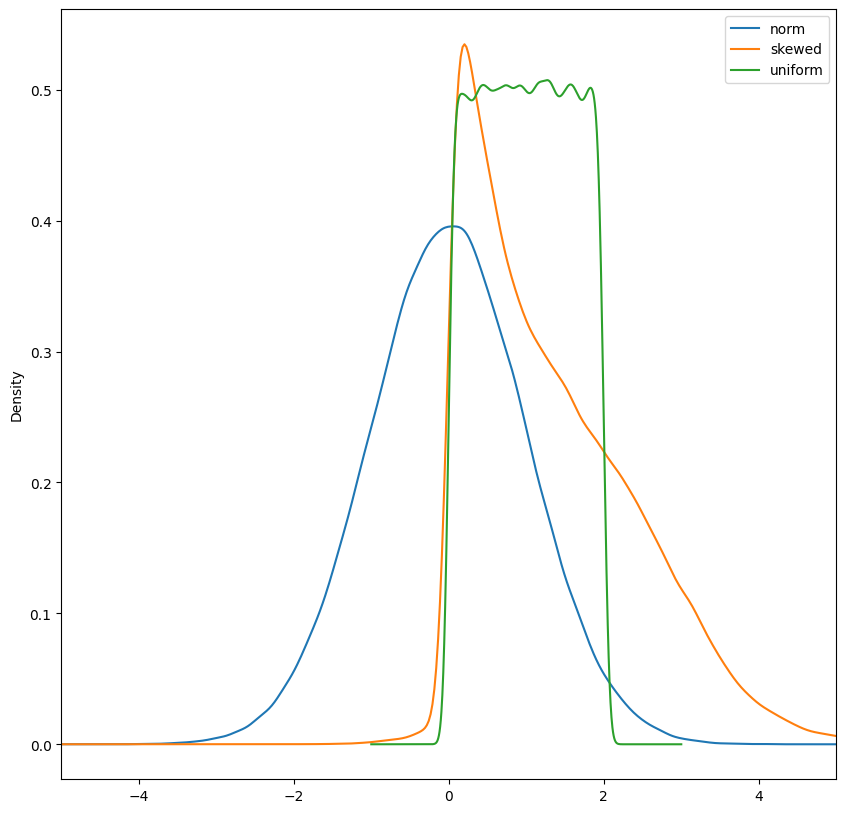

In [23]:
# Plot the density of all three datasets
data_df.plot(kind="density",
             figsize=(10, 10),
             xlim=(-5, 5))

* Now let's check the skewness of each of the distributions.
* Since skewness measures asymmetry, we'd expect to see low skewness for all of the distributions except the skewed one, because all the others are roughly symmetric:

In [24]:
data_df.skew() # Check skewness of each distribution

norm       0.004808
skewed     0.992714
uniform   -0.000565
dtype: float64

Now let's check kurtosis

In [25]:
data_df.kurt() # Check kurtosis of each distribution

norm       0.002738
skewed     1.178532
uniform   -1.195658
dtype: float64

* As we can see from the output, the normally distributed data has a kurtosis near zero,
* the flat distribution has negative kurtosis and
* the one distributions with more data in the tails vs the center have higher kurtosis.

## Wrap Up
Descriptive statistics help you explore features of your data, like center, spread and shape by summarizing them with numerical measurements. Descriptive statistics help inform the direction of an analysis and let you communicate your insights to others quickly and succinctly. In addition, certain values, like the mean and variance, are used in all sorts of statistical tests and predictive models.

In this lesson, we generated a lot of random data to illustrate concepts, but we haven't actually learned much about the functions we've been using to generate random data. In the next lesson, we'll learn about probability distributions, including how to draw random data from them.